#                                               Credit Card Fraud System


We will build a model to prevent unauthorized transactions even attackers possess valid card credentials.

<a id='Data'></a>
## Data

We will use **model-centric Ai Development** concept, which holding the data fixed and iteratively improve the model
becouse the data is structured

### Setup

In [39]:
# The Packages we will need for Data stage.

import os
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from torchmetrics import Precision , Recall , Accuracy , F1Score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from torchmetrics.classification import ConfusionMatrix
from torch.utils.data import DataLoader, TensorDataset

#### Define Data

In [2]:
# extract x and y distrbutions 

df = pd.read_csv('/Users/mahmoud/Desktop/Credit Card Fraud Detection System/creditcard.csv')

# extract x distrburion

x_dist = df.iloc[: , :-1]

# extract y distburation

y_dist = df.iloc[: , [-1]]

# display first 5 rows in the dataset.
df.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# see the more information about x_dist

x_dist.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,6.418678e-16,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000


In [4]:
# check data balance for y_dist

print(np.round(y_dist.value_counts(normalize = True) * 100 , 2))

Class
0        99.83
1         0.17
Name: proportion, dtype: float64


As you can see above the data is skewed and imbalanced, so will use some techinques like add more weights for postive class(fraud).

if we leave that without apply any of techinques to solve imbalanced dataset problem, the negtive class will eliminte and the model ignore postitive class.

#### Preprocessing 

We will care about more with postitive class(fraud) because that is a rare class and the model struggles with the rare class.

Unfortunately, due to confidentiality issues, we cannot provide the original features and more background information about the data.

The Features V1, V2, … V28 are the principal components obtained with PCA, the only features which have not been transformed with PCA are 'Time' and 'Amount'.

We clean data based on Time and Amount features because these are known for us from orginal data.

In [5]:
# 
df.shape

(284807, 31)

In [6]:
# Creating a dataset sorting by time

df_sorted = df.sort_values(by = 'Time')

df_sorted

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0


In [7]:
# count how many example for postive class

postive_examples = np.count_nonzero(df_sorted['Class'] == 1) # 492

# check the amount which is bigger than 75% of the data for all classes

df_sorted[df_sorted['Amount'] > np.percentile(df_sorted['Amount'] , 75)]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
12,10.0,1.249999,-1.221637,0.383930,-1.234899,-1.485419,-0.753230,-0.689405,-0.227487,-2.094011,...,-0.231809,-0.483285,0.084668,0.392831,0.161135,-0.354990,0.026416,0.042422,121.50,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284766,172756.0,-0.564412,-0.340899,0.001107,-1.775612,0.116635,1.116266,-0.211710,0.823119,-1.024449,...,-0.146040,-0.181247,0.354040,-0.371682,-0.351548,0.511621,-0.168182,-0.155795,95.63,0
284771,172759.0,1.894910,-0.427906,-2.184267,0.159979,0.587740,-0.557966,0.510524,-0.281590,0.785446,...,0.122775,0.202373,-0.125329,0.017737,0.396759,-0.515948,-0.039485,-0.040441,124.99,0
284778,172764.0,-0.764523,0.588379,-0.907599,-0.418847,0.901528,-0.760802,0.758545,0.414698,-0.730854,...,0.003530,-0.431876,0.141759,0.587119,-0.200998,0.267337,-0.152951,-0.065285,80.00,0
284799,172783.0,-1.775135,-0.004235,1.189786,0.331096,1.196063,5.519980,-1.518185,2.080825,1.159498,...,0.103302,0.654850,-0.348929,0.745323,0.704545,-0.127579,0.454379,0.130308,79.99,0


In [8]:
# extract postive_examples and see their amounts

postive_data = df_sorted[df_sorted['Class'] == 1]

# claculate the mean for postive examples amount

postive_data_amounts_mean = np.round(postive_data['Amount'].mean() , 2)

postive_data_amounts_mean

np.float64(122.21)

In [9]:
postive_data

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
541,406.0,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.00,1
623,472.0,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00,1
4920,4462.0,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,...,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,239.93,1
6108,6986.0,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,...,0.573574,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,59.00,1
6329,7519.0,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,...,-0.379068,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1.00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279863,169142.0,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,...,0.778584,-0.319189,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,390.00,1
280143,169347.0,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,...,0.370612,0.028234,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,0.76,1
280149,169351.0,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,...,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,77.89,1
281144,169966.0,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,...,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,245.00,1


(array([410.,  40.,  17.,  14.,   2.,   2.,   4.,   1.,   1.,   1.]),
 array([   0.   ,  212.587,  425.174,  637.761,  850.348, 1062.935,
        1275.522, 1488.109, 1700.696, 1913.283, 2125.87 ]),
 <BarContainer object of 10 artists>)

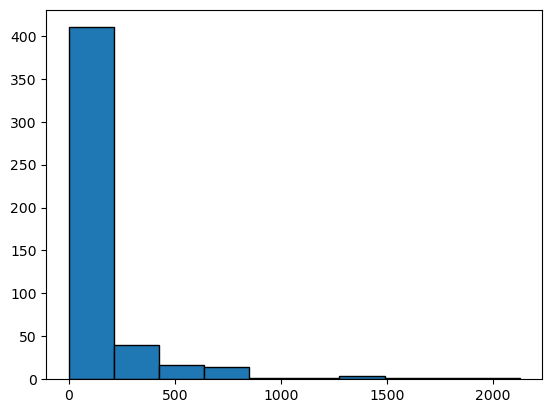

In [10]:
# plot the postive examples distrbution 

plt.hist(postive_data['Amount'], bins=10, edgecolor='black')

### Insights from postive data:

- Since we have 492 examples for postive data, the most of the amount of the data starting from 0 to 410.
- Higher amount doesn't mean fraud transaction.
- Getting 27 examples zeros which we could think the frauder tests the card validation first.

In [11]:
# sort data for each time based on the amounts 

df_sorted_by_amount = df_sorted.sort_values(by = ['Time' , 'Amount']).reset_index()

# drop index column 

df_sorted_by_amount = df_sorted_by_amount.drop(columns = 'index' , axis = 1)

df_sorted_by_amount

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
1,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
2,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
3,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
4,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284805,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0


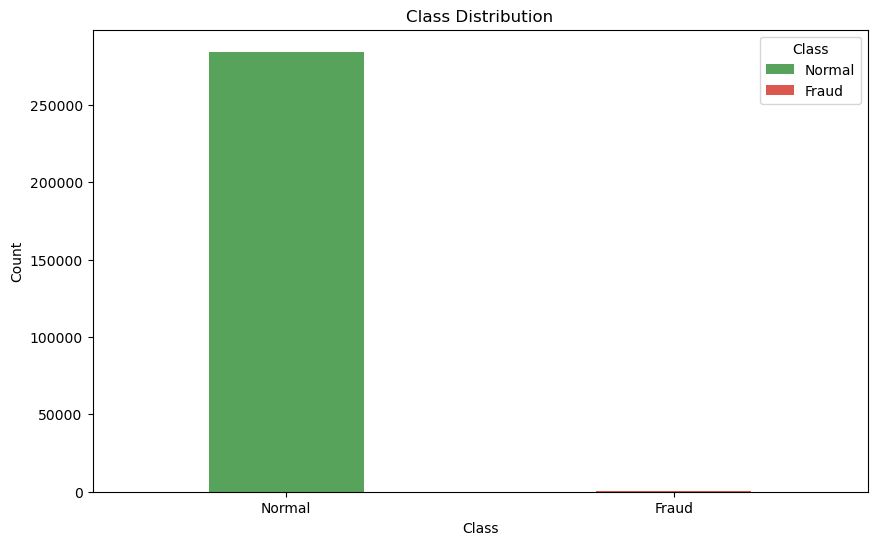

In [12]:
# plot the Label distrution 

df_copy = df.copy()
df_copy["Class"] = df["Class"].map({0: "Normal", 1: "Fraud"})

palette = {
    "Normal": "#4CAF50",   
    "Fraud": "#F44336"     
}
plt.figure(figsize=(10 , 6))
sns.countplot(data = df_copy , x="Class" , palette = palette , legend= True , hue = 'Class' , width=0.4)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.savefig('./Class_Distribution')
plt.show()

<a id='Establish baseline'></a>
## Establish baseline

Establishing a performance baseline early on allows you to better understand whether your updated model is an improvement, 
and if so
by how much.
We will start with a prototype model to determine a baseline.

In [13]:
# Create a prototype model 

class PrototypeModel(nn.Module):
    
   """
   
   Simple feedforward neural network for binary classification.
        
   Layers:
   512 → 128 → 64 → 1 with BatchNorm and ReLU.
   Final Sigmoid outputs probability.
        
   Input: (df.shape[0], 512)
   Output: (df.shape[0], 1)
   
   """

   def __init__(self , *args , **kwargs):
       
       super().__init__(*args , **kwargs)

       # initilize model'layers

       self.fc1 = nn.Linear(30 , 128) # fc1
       self.bn1 = nn.BatchNorm1d(128) # bn1
       self.relu = nn.ReLU() # relu

       self.fc2 = nn.Linear(128 , 64) # fc2
       self.bn2 = nn.BatchNorm1d(64) # bn2

       self.fc3 = nn.Linear(64, 1) #fc3
       self.sigmoid = nn.Sigmoid() # sigmoid
       
   def forward(self , x):

       x = self.fc1(x)
       x = self.bn1(x)
       x = self.relu(x)

       x = self.fc2(x)
       x = self.bn2(x)

       x = self.fc3(x)
       x = self.sigmoid(x)

       return x


## Organize Data

Since Our Model is built by pytorch , based on pytorch documantations, we must convert the input X and target Y into tensor before feed them into the model.
In addition, Creating the optimizer , loss , and finally the model code instructions .

In [14]:
# base folder for saving files for this model and all need from data splits.

BASE_DIR = './Prototype Model'

# Create the base folder first

os.makedirs(BASE_DIR , exist_ok= True)

# Create Data and model folders

os.makedirs(BASE_DIR +'/Data' , exist_ok= True)
os.makedirs(BASE_DIR +'/Model' , exist_ok = True)

# split data for prototype model 
X_train , X_test , y_train , y_test = train_test_split(x_dist , y_dist , test_size=0.2, shuffle=True , random_state=42)

# save all data using .to_csv()

X_train.to_csv(BASE_DIR +'/Data/X_train.csv')
y_train.to_csv(BASE_DIR +'/Data/y_train.csv')
X_test.to_csv(BASE_DIR +'/Data/X_test.csv')
y_test.to_csv(BASE_DIR +'/Data/y_test.csv')


In [15]:
# Convert X_train , y_train , X_test , y_test into tensors

X_train_tensor = torch.tensor(X_train.to_numpy().tolist()).float() # should be float data type 
y_train_tensor = torch.tensor(y_train.to_numpy().tolist()).float() #

X_test_tensor = torch.tensor(X_test.to_numpy().tolist()).float() #
y_test_tensor = torch.tensor(y_test.to_numpy().tolist()).float() #

print(X_train_tensor,y_train_tensor)

tensor([[ 1.4335e+05,  1.9550e+00, -3.8078e-01,  ...,  4.5168e-02,
         -4.7145e-02,  9.9900e+00],
        [ 1.1717e+05, -4.0098e-01, -6.2694e-01,  ..., -3.7047e-01,
         -1.4479e-01,  4.5900e+01],
        [ 1.4956e+05,  7.2509e-02,  8.2057e-01,  ...,  2.0639e-01,
          7.0288e-02,  1.1990e+01],
        ...,
        [ 7.9795e+04, -1.4661e-01,  9.9295e-01,  ..., -1.2114e-01,
         -1.9620e-01,  3.9400e+00],
        [ 8.7931e+04, -2.9486e+00,  2.3548e+00,  ...,  4.9691e-01,
          3.3582e-01,  1.0000e+00],
        [ 7.6381e+04,  1.2332e+00, -7.8485e-01,  ...,  1.2166e-03,
          3.8588e-02,  1.1300e+02]]) tensor([[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]])


In [16]:
NUM_EPOCHS = 10
# Instantiate model object

model = PrototypeModel()

# Instantiate the optimizer and criterion objects 

opt = torch.optim.Adam(model.parameters() , lr = 0.001)
criterion = nn.BCELoss()

# Write down performing model code

for epoch in range(NUM_EPOCHS):
    
    opt.zero_grad()
    predications = model(X_train_tensor)
    
    loss = criterion(predications,  y_train_tensor)
    loss.backward()
    
    opt.step()

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Loss: {loss.item():.4f}")

Epoch 1/10, Loss: 0.7067
Epoch 2/10, Loss: 0.6658
Epoch 3/10, Loss: 0.6726
Epoch 4/10, Loss: 0.6678
Epoch 5/10, Loss: 0.6600
Epoch 6/10, Loss: 0.6560
Epoch 7/10, Loss: 0.6547
Epoch 8/10, Loss: 0.6537
Epoch 9/10, Loss: 0.6517
Epoch 10/10, Loss: 0.6490


In [17]:
# save the prototype model
torch.save(model, BASE_DIR+"/Model/model.pth")

In [18]:
# Instantiate Percision , Recall and Accuracy 

metric_percision = Precision(task='multiclass' , num_classes=2, average='macro')
metric_recall = Recall(task='multiclass' , num_classes=2 , average='macro')
metric_accuracy = Accuracy(task='multiclass', num_classes=2 , average='macro')

# evaluate the prototype model 

model.eval()

with torch.no_grad():
    
    outputs = model(X_test_tensor)
    preds = (outputs > 0.5).int()
    
    preds = preds.squeeze()
    y_true = y_test_tensor.squeeze().int()

    metric_percision(preds, y_true)
    metric_recall(preds, y_true)
    metric_accuracy(preds, y_true)
    
# compute all metrics 

precision = metric_percision.compute()
recall = metric_recall.compute()
accuracy = metric_accuracy.compute()

print(f'Precision: {precision:.2f} , Recall: {recall:.2f} , Accurcay: {accuracy:.2f}')

Precision: 0.50 , Recall: 0.50 , Accurcay: 0.50


Finally, the baseline is a 46% as accuracy of prototype model. 

We can start the experiments to improve the model performance ,in addition record these metrics in the text experiment file.



#### Create a balanced train/dev/test split

Another thing we can look at is the data splits. 
Since we have skewed dataset you should split data into train , dev and test sets 
and preserve the data distrbuation for each split. 


In [19]:
# Print the percentage of each class in the train set
y_train.Class.value_counts(normalize=True).sort_index().mul(100).round(1).astype(str) + '%'

Class
0    99.8%
1     0.2%
Name: proportion, dtype: object

In [20]:
# Print the percentage of each class in the test set
y_test.Class.value_counts(normalize=True).sort_index().mul(100).round(1).astype(str) + '%'

Class
0    99.8%
1     0.2%
Name: proportion, dtype: object

In [21]:
# Resplit x_dist and y_dist into 3 different splits(train , dev , test) and preserving the the classes distrbution like the orginal data
# using str
X_train , X_temp, y_train , y_temp = train_test_split(x_dist , y_dist , test_size=0.4 ,stratify=y_dist,shuffle=True,random_state=42)
X_dev , X_test , y_dev , y_test = train_test_split(X_temp , y_temp , test_size=0.5 , stratify=y_temp ,shuffle=True, random_state = 42)


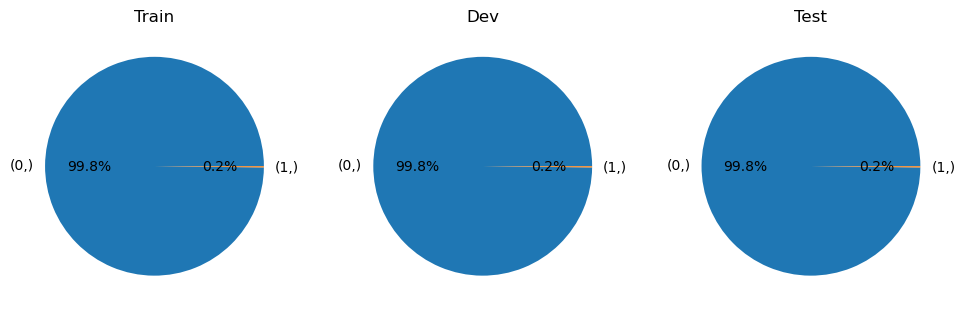

In [22]:
# Display if the distrbution in train , dev and test sets are the same.

# Create figure
plt.figure(figsize=(12, 4))

# Train
plt.subplot(1, 3, 1)
y_train.value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Train")
plt.ylabel("")

# Dev
plt.subplot(1, 3, 2)
y_dev.value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Dev")
plt.ylabel("")

# Test
plt.subplot(1, 3, 3)
y_test.value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Test")
plt.ylabel("")

plt.show()


As you can see the train , dev and test sets has the same distrbution just like the orginal dataset,

but the skew still in these sets so we will treat that problem by apply some techinques to the model. 

Since we use Model-Centric Ai Development , As we mentioned above , we'll make the data fixed.

# Modeling

In this section we apply techinques to improve the model, As we know , we got the accuracy from prototype model(46%) so , it's very low but this is the first step in improving the performance.

## Experiment 1 

We will use weight loss techinque to penalize the model learns rare class which here in our data is postive class.

In [23]:
# Set the base directory for the first experiment

BASE_DIR = './E1'

# Create Data and model folders

os.makedirs(BASE_DIR +'/Data' , exist_ok= True)
os.makedirs(BASE_DIR +'/Model' , exist_ok = True)

# save all data using .to_csv()

X_train.to_csv(BASE_DIR +'/Data/X_train.csv')
y_train.to_csv(BASE_DIR +'/Data/y_train.csv')
X_test.to_csv(BASE_DIR +'/Data/X_test.csv')
y_test.to_csv(BASE_DIR +'/Data/y_test.csv')

#

In [24]:
# Convert X_train , y_train , X_test , y_test into tensors

X_train_tensor = torch.tensor(X_train.to_numpy().tolist()).float() # should be float data type 
y_train_tensor = torch.tensor(y_train.to_numpy().tolist()).float() #

X_dev_tensor = torch.tensor(X_dev.to_numpy().tolist()).float() #
y_dev_tensor = torch.tensor(y_dev.to_numpy().tolist()).float() #

X_test_tensor = torch.tensor(X_test.to_numpy().tolist()).float() #
y_test_tensor = torch.tensor(y_test.to_numpy().tolist()).float() #

print(X_train_tensor,y_train_tensor)

# initilize dataset objects.

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
dev_dataset = TensorDataset(X_dev_tensor, y_dev_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# initilize loaders for splits

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
dev_loader = DataLoader(dev_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

tensor([[ 7.1174e+04, -2.1083e+00,  1.1734e+00,  ..., -3.4829e-01,
          2.1530e-01,  1.9990e+01],
        [ 1.6968e+05,  2.3140e+00, -1.3111e+00,  ..., -2.4483e-02,
         -7.6422e-02,  1.5000e+01],
        [ 1.1113e+05,  2.1049e+00,  1.5528e-01,  ..., -1.6524e-02,
         -5.3868e-02,  1.0000e+00],
        ...,
        [ 6.0764e+04, -1.4979e+00,  6.5792e-01,  ..., -4.4844e-01,
          4.5178e-02,  3.6990e+01],
        [ 3.5301e+04,  1.0698e+00,  7.2105e-02,  ...,  3.1014e-02,
          2.4886e-02,  4.5420e+01],
        [ 2.8847e+04, -5.9812e-01,  7.7504e-01,  ...,  3.7858e-01,
          2.0637e-01,  6.9900e+00]]) tensor([[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]])


In [25]:
# create a new model for experiment to see the improvement over prototype.

class ExpermientModel_1(nn.Module):
    
   """
   
   Simple feedforward neural network for binary classification.
        
   Layers:
   512 → 128 → 64 → 1 with BatchNorm and ReLU.
   Final Sigmoid outputs probability.
        
   Input: (df.shape[0], 512)
   Output: (df.shape[0], 1)
   
   """

   def __init__(self , *args , **kwargs):
       
       super().__init__(*args , **kwargs)

       # initilize model'layers

       self.fc1 = nn.Linear(30 , 128) # fc1
       self.bn1 = nn.BatchNorm1d(128) # bn1
       self.relu = nn.ReLU() # relu

       self.fc2 = nn.Linear(128 , 64) # fc2
       self.bn2 = nn.BatchNorm1d(64) # bn2

       self.fc3 = nn.Linear(64, 1) #fc3
       self.sigmoid = nn.Sigmoid() # sigmoid
       
   def forward(self , x):

       x = self.fc1(x)
       x = self.bn1(x)
       x = self.relu(x)

       x = self.fc2(x)
       x = self.bn2(x)

       x = self.fc3(x)
       x = self.sigmoid(x)

       return x

In [26]:
# Instantiate weight for loss based on the classes distrbution 
# postive class(1) is 0.02 and negative class(0) is 99.8.

NUM_EPOCHS = 20


model = ExpermientModel_1()

# Instantiate the optimizer and criterion objects 

opt = torch.optim.Adam(model.parameters() , lr = 0.001)

# pos_weight = torch.tensor([ (y_train_tensor == 0).sum() / (y_train_tensor == 1).sum() ])

criterion = nn.BCEWithLogitsLoss(pos_weight = torch.tensor([200]))
# Write down performing model code

for epoch in range(NUM_EPOCHS):
    
    # define training loss 
    
    train_loss = 0.0
    
    for  X_batch , y_batch in train_loader:
        
        opt.zero_grad()
        predictions = model(X_batch)
    
        loss = criterion(predictions,  y_batch.float()) 
        loss.backward()
         
        opt.step()
        
        train_loss += loss.item() 
    epoch_loss = train_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Loss: {epoch_loss:.4f}")

Epoch 1/20, Loss: 0.9461
Epoch 2/20, Loss: 0.9313
Epoch 3/20, Loss: 0.9312
Epoch 4/20, Loss: 0.9268
Epoch 5/20, Loss: 0.8995
Epoch 6/20, Loss: 0.8555
Epoch 7/20, Loss: 0.8651
Epoch 8/20, Loss: 0.8710
Epoch 9/20, Loss: 0.8715
Epoch 10/20, Loss: 0.8496
Epoch 11/20, Loss: 0.8637
Epoch 12/20, Loss: 0.8418
Epoch 13/20, Loss: 0.8601
Epoch 14/20, Loss: 0.8567
Epoch 15/20, Loss: 0.8357
Epoch 16/20, Loss: 0.8401
Epoch 17/20, Loss: 0.8360
Epoch 18/20, Loss: 0.8365
Epoch 19/20, Loss: 0.8446
Epoch 20/20, Loss: 0.8288


In [92]:
# save the E1 model
torch.save(model.state_dict(), BASE_DIR+"/Model/model.pth")

## Perform Error Analysis


The first iteration of your model will likely underperform and you will need to make adjustments to make it better. Error analysis helps you determine which part of the process you need to tweak to give the biggest improvement. Likewise, it helps you avoid focusing on parts that do not greatly affect the results.



#### Prioritizing What to Work On

Looking at the performance of your model on different categories of the data will help you decide how to improve its performance. In this case, you will evaluate the model postive class(fraud) due to imbalance dataset.

In [46]:
# define metrics to evaluate the experiment model 1
metric_percision = Precision(task='multiclass' , num_classes=2, average='macro')
metric_recall = Recall(task='multiclass' , num_classes=2 , average='macro')
metric_accuracy = Accuracy(task='multiclass', num_classes=2 , average='macro')
metric_f1_score = F1Score(task='multiclass', num_classes=2 , average='macro')
# define conf. matrix 

cm_metric = ConfusionMatrix(task='multiclass' , num_classes=2)

# define metrics evaluate the experiment model 1 per class 

metric_percision_per_class = Precision(task='multiclass' , num_classes=2, average=None)
metric_recall_per_class = Recall(task='multiclass' , num_classes=2 , average=None)
metric_accuracy_per_class = Accuracy(task='multiclass', num_classes=2 , average=None)
metric_f1_score_per_class = F1Score(task='multiclass', num_classes=2 , average=None)

# stop training and start evaluation for the model

model.eval()

with torch.no_grad():
    
    for X_dev_batch , y_dev_batch in dev_loader:
        
        outputs = model(X_dev_batch)
        preds = (outputs > 0.5).int()
        
        preds = preds.view(-1)
        y_true = y_dev_batch.view(-1).int()

        # Calculate all metrics per class
        
        metric_percision_per_class(preds, y_true)
        metric_recall_per_class(preds, y_true)
        metric_accuracy_per_class(preds, y_true)
        metric_f1_score_per_class(preds , y_true)
        # Calculate conf. matri
        
        cm_metric(preds , y_true)

        # Calculate all metrics for all classes
        
        metric_percision(preds, y_true)
        metric_recall(preds, y_true)
        metric_accuracy(preds, y_true)
        metric_f1_score(preds , y_true)
# compute all metrics 

precision = metric_percision.compute()
recall = metric_recall.compute()
accuracy = metric_accuracy.compute()
f1_score = metric_f1_score.compute()
# compute conf. matrix

cm = cm_metric.compute()

# compute all metrcis per class
precision_per_class = metric_percision_per_class.compute()
recall_per_class = metric_recall_per_class.compute()
accuracy_per_class = metric_accuracy_per_class.compute()
f1_score_per_class = metric_f1_score_per_class.compute()


In [47]:
# Get the metrics
print(f'Precision: {precision:.2f} , Recall: {recall:.2f} , Accurcay: {accuracy:.2f} , F1_Score: {f1_score:.2f}')

Precision: 0.80 , Recall: 0.90 , Accurcay: 0.90 , F1_Score: 0.84


In [48]:
# Get the metrics for each class

class_names = ["Normal","Fraud"]

for i in range(len(class_names)):
    print(f"{class_names[i]}:")
    print(f"  Precision: {precision_per_class[i]:.4f}")
    print(f"  Recall:    {recall_per_class[i]:.4f}")
    print(f"  Accuracy:  {accuracy_per_class[i]:.4f}")
    print(f"  F1 Score:  {f1_score_per_class[i]:.4f}")

    print("-" * 30)

Normal:
  Precision: 0.9997
  Recall:    0.9991
  Accuracy:  0.9991
  F1 Score:  0.9994
------------------------------
Fraud:
  Precision: 0.6031
  Recall:    0.8061
  Accuracy:  0.8061
  F1 Score:  0.6900
------------------------------


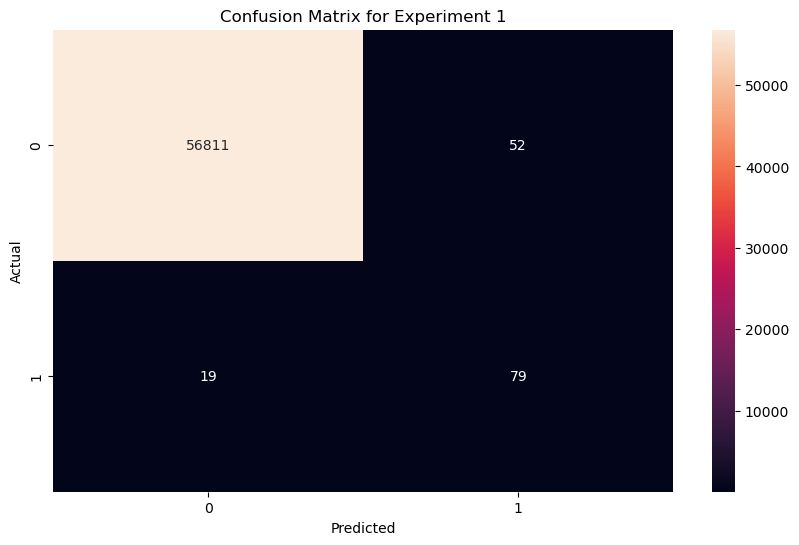

In [31]:
# Display the confinuison matrix to see the evaluation of the model.

plt.figure(figsize=(10 , 6))

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Experiment 1")

plt.savefig(BASE_DIR+'/Confusion_Matrix_for_Experiment.png')
plt.show()


### ٍResult Experiment 1



- As we see the improvement over than the prototype model, and handle the rare class more than in the previous one.
  
- We apply loss weight and that makes for changing in the model performance and solve the problem of the skewed data.
  
- We still try another experiment to improve the model , but before the that let's save the result in the `experiment.csv`.


# Deployment 


Now that we've cleaned the data and retrained the model prototype, we want to deploy it and start receiving new requests. This opens up new challenges that includes both software engineering and machine learning issues. We will have to monitor potential problems and make sure that your model stays performant.

## Setup

In [67]:
# The Packages we will need for Deployment stage.
import logging
from fastapi import FastAPI
from pydantic import BaseModel,create_model


## Monotior and Maintain System



Deplying an ML system is not the end of the project. Over time the performance will degrade as gradual change or sudden shock makes the incoming data less like that the model was trained on.

So we must record inputs , outputs and software metrics and analyze and plot what's going on under the hood.

Using sqlite, we will record all metrics to track the model in deployment stage.


In [129]:
# Create engine object to connect with the logging database that we've just created below.

engine = sqlite3.connect("./serving/logging.db")
cursor = engine.cursor()


In [130]:
# Now , we track every metric involving software and output metrics 
# Becouse the input is a structured data and has more featrues we have to create a sperate dataset for inputs.

df_monitor = pd.read_sql_query("SELECT * FROM inference_logs" , engine)

df_monitor.head(5)

,id,request_id,timestamp,probability_output,prediction,latency_ms,throughput_rps,cpu_percent,memory_percent,status,error_message
0,1,1c62ffff-40aa-4729-9f94-e4286d2cd277,2026-04-08T17:27:38.511386,1.000000,1,11.485100,0.329577,0.0,83.7,SUCCESS,None
1,2,be86f58a-f41d-498f-9d7b-8439e58995e3,2026-04-08T17:33:09.980512,0.000552,0,36.447048,0.005979,13.3,83.9,SUCCESS,None
2,3,f45bc609-c17c-42d8-9543-67fcc943b013,2026-04-08T17:35:23.083795,0.001296,0,3.021955,0.006416,15.1,83.8,SUCCESS,None
3,4,2de70050-2d97-40ab-9eef-7cba7f7ce82d,2026-04-08T17:35:56.141618,0.000048,0,2.699852,0.007989,18.9,84.3,SUCCESS,None
4,5,00d053df-ac61-4591-96a3-0a81eeb3bb6c,2026-04-08T17:36:08.753794,1.000000,1,4.969120,0.009741,20.9,83.9,SUCCESS,None


## Conclusion



- We've successfully applied crucial stages to build a solid real-world Credit Card Fraud System staring from scoping to deployment.
  
- First,we build a prototype model to see if this system is workable and worth deploying,and
  for establishing a baseline to track the next improvements.

- in addition , applying some techinques to the prototype model gives high performance to the model as we mentioned in `expermient file`.

- lastly to complete the life cycle for the system we cover the deployment stage and track any server issue , concept drift and so on.